# Runtime Scaling Benchmark

Sweep small sample counts and analytic/finite-shot settings to inspect runtime and metric scaling for representative QML workflows against classical references.

The defaults are intentionally smoke-scale. Increase sample sizes, seeds, shot counts, and model-specific training settings for stronger runs.

In [1]:
from io import BytesIO
from pathlib import Path
import sys

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
from IPython.display import Image, display

from qml.benchmarks import benchmark_runtime_scaling
from qml.reporting import format_table

## Classification Scaling

Compare a fixed quantum reservoir feature map with logistic regression while increasing the sample count.

In [2]:
classification = benchmark_runtime_scaling(
    task="classification",
    models=["quantum_reservoir", "logistic_regression"],
    sample_sizes=[24, 32],
    shots_values=[None],
    seeds=[0],
    dataset="moons",
    model_kwargs={"quantum_reservoir": {"n_layers": 1}},
)

print(
    format_table(
        classification["scaling_summary"],
        title="Classification runtime scaling",
        columns=[
            "model",
            "sample_size",
            "shots",
            "primary_metric_mean",
            "runtime_seconds_mean",
        ],
        float_digits=4,
    )
)

Classification runtime scaling
+---------------------+-------------+----------+---------------------+----------------------+
| model               | sample_size | shots    | primary_metric_mean | runtime_seconds_mean |
+---------------------+-------------+----------+---------------------+----------------------+
| quantum_reservoir   | 24          | analytic | 0.3333              | 0.09198              |
| logistic_regression | 24          | analytic | 0.8333              | 0.005064             |
| quantum_reservoir   | 32          | analytic | 0.5                 | 0.1207               |
| logistic_regression | 32          | analytic | 0.75                | 0.004889             |
+---------------------+-------------+----------+---------------------+----------------------+


## Regression Scaling

Compare a quantum reservoir regressor with ridge regression on a compact synthetic sine task.

In [3]:
regression = benchmark_runtime_scaling(
    task="regression",
    models=["quantum_reservoir_regressor", "ridge_regression"],
    sample_sizes=[24, 32],
    shots_values=[None],
    seeds=[0],
    dataset="sine",
    model_kwargs={"quantum_reservoir_regressor": {"n_layers": 1}},
)

print(
    format_table(
        regression["scaling_summary"],
        title="Regression runtime scaling",
        columns=[
            "model",
            "sample_size",
            "shots",
            "primary_metric_mean",
            "runtime_seconds_mean",
        ],
        float_digits=4,
    )
)

Regression runtime scaling
+-----------------------------+-------------+----------+---------------------+----------------------+
| model                       | sample_size | shots    | primary_metric_mean | runtime_seconds_mean |
+-----------------------------+-------------+----------+---------------------+----------------------+
| quantum_reservoir_regressor | 24          | analytic | 0.9823              | 0.09987              |
| ridge_regression            | 24          | analytic | 0.6593              | 0.002816             |
| quantum_reservoir_regressor | 32          | analytic | 1.003               | 0.0995               |
| ridge_regression            | 32          | analytic | 0.6347              | 0.002685             |
+-----------------------------+-------------+----------+---------------------+----------------------+


## Runtime Plot

Plot runtime means from the flat `scaling_summary` rows.

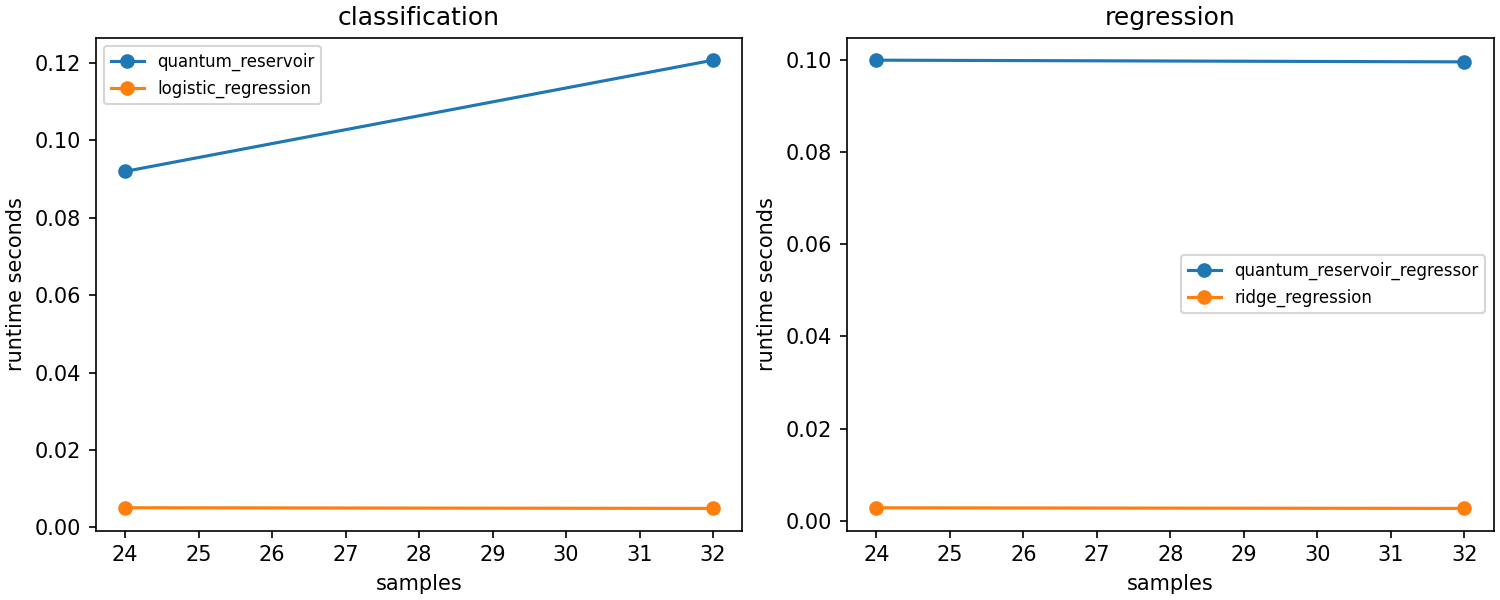

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

for ax, result, title in [
    (axes[0], classification, "classification"),
    (axes[1], regression, "regression"),
]:
    rows = result["scaling_summary"]
    for model in result["models"]:
        model_rows = [row for row in rows if row["model"] == model]
        ax.plot(
            [row["sample_size"] for row in model_rows],
            [row["runtime_seconds_mean"] for row in model_rows],
            marker="o",
            label=model,
        )
    ax.set_title(title)
    ax.set_xlabel("samples")
    ax.set_ylabel("runtime seconds")
    ax.legend(fontsize=8)

buffer = BytesIO()
fig.savefig(buffer, format="png", dpi=150)
display(Image(data=buffer.getvalue()))
plt.close(fig)

## Validation

In [5]:
validation = {
    "classification_rows": len(classification["scaling_summary"]),
    "regression_rows": len(regression["scaling_summary"]),
    "classification_models": classification["models"],
    "regression_models": regression["models"],
    "passed": bool(classification["scaling_summary"] and regression["scaling_summary"]),
}

print(format_table(validation, title="Validation"))

Validation
+-----------------------+-------------------------------------------------+
| Metric                | Value                                           |
+-----------------------+-------------------------------------------------+
| classification_rows   | 4                                               |
| regression_rows       | 4                                               |
| classification_models | [quantum_reservoir, logistic_regression]        |
| regression_models     | [quantum_reservoir_regressor, ridge_regression] |
| passed                | True                                            |
+-----------------------+-------------------------------------------------+
